<a href="https://colab.research.google.com/github/nika19du/LangGraph-Agent-Workflows/blob/master/Multi_Agent_AI_Developer_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q langgraph langchain langchain-openai langchain-anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 12.3 MB/s eta 0:00:00


In [68]:
import os
import subprocess

from html import escape
from IPython.display import Image, HTML, display
from google.colab import userdata
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from typing import Annotated, List, TypedDict, Literal
from langchain_core.runnables import Runnable

from langchain_core.messages import HumanMessage, SystemMessage,BaseMessage
from langchain_core.tools import tool

from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, Interrupt, Send, interrupt
from langgraph.prebuilt import ToolNode

openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))

anthropic_api_key = userdata.get("ANTHROPIC_API_KEY")

print("Loaded:", anthropic_api_key is not None)
print("Length:", len(anthropic_api_key) if anthropic_api_key else 0)
print("Prefix:", anthropic_api_key[:10] if anthropic_api_key else None)

def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(output_png, format="png"))

from html import escape

def print_interrupts(interrupts: List[Interrupt]):
    for interrupt_item in interrupts:
        value = interrupt_item.value

        message = escape(str(value.get("message", "")))
        workflow_status = escape(str(value.get("workflow_status", "")))
        proposed_content = escape(str(value.get("proposed_content", "")))

        review = value.get("review", {})
        status = escape(str(review.get("status", "")))
        score = escape(str(review.get("score", "")))
        issues = escape(str(review.get("issues", [])))
        feedback = escape(str(review.get("feedback", "")))
        revision_count = escape(str(value.get("revision_count", 0)))

        display(
            HTML(
                f"""
                <div style="
                    border: 1px dashed red;
                    margin: 10px 0;
                    padding: 15px;
                ">
                    <h3>Human Review Required</h3>

                    <p><b>{message}</b></p>

                    <h4>Proposed Content</h4>
                    <pre>{proposed_content}</pre>

                    <p><b>Workflow Status:</b> {workflow_status}</p>

                    <h4>AI Review</h4>
                    <p><b>AI Review Status:</b> {status}</p>
                    <p><b>AI Review Score:</b> {score}/10</p>
                    <p><b>Issues:</b> {issues}</p>
                    <p><b>Feedback:</b> {feedback}</p>
                    <p><b>Revisions so far:</b> {revision_count}</p>

                    <p>
                        Resume with <code>approve</code>
                        or provide revision feedback.
                    </p>
                </div>
                """
            )
        )

Loaded: True
Length: 108
Prefix: sk-ant-api


In [5]:
coding_model = ChatOpenAI(
    model = "gpt-5.6-luna",
    api_key=openai_api_key,
    reasoning_effort="none"
)

review_model=ChatAnthropic(
    model="claude-sonnet-4-6",
    api_key= anthropic_api_key
)

## Coding Sub-graph

In [69]:
class ReviewResult(BaseModel):
    status: Literal["approved","changes_required"] = Field(description="Whether the proposed solution is approved or needs revision.")
    score: int = Field(ge=1, le= 10, description="Overall code quality score from 1 to 10.")
    issues: list[str] = Field(default_factory= list, description="Problems found in the proposed implementation.")
    feedback: str = Field(default="", description = "Specific instructions for the coding agent if revision is needed.")


class CodingState(TypedDict):
    user_request: str
    task_type: Literal['create', 'modify']

    file_path:str
    original_content: str
    proposed_content: str

    review: dict | None #ReviewResult | None

    human_feedback: str
    revision_count: int
    final_answer: str

    messages: Annotated[list[BaseMessage], add_messages]

In [8]:
structured_review_model = review_model.with_structured_output(ReviewResult)

structured_review_model = review_model.with_structured_output(ReviewResult)

/usr/local/lib/python3.13/dist-packages/pydantic/json_schema.py:2463: PydanticJsonSchemaWarning: Default value <class 'list'> is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [70]:
@tool
def read_file(file_path: str) -> str:
    """
    Read a text-based file from the Google Colab enviornment.

    Args:
        file_path: Absolute or relative path to the file.

    Returns:
        The file content as a string.
    """

    path = Path(file_path)

    if not path.exists():
        return f"Error: File '{file_path}' not found."

    if not path.is_file():
        return f"Error: '{file_path}' is not a file."

    try:
      with path.open(mode="r") as file:
          return file.read()
    except Exception as e:
        return f"Error: Could not read file: {e}"


@tool
def write_file(file_path: str, content: str) -> str:
    """
    Write approved text content to a file in the Google Colab environment.

    This tool should only be used after human approval.

    Args:
      file_path: Path to the target file.
      content: Full content that should be written.

    Returns:
      A status message.
    """

    path = Path(file_path)

    try:
        path.parent.mkdir(
            parents = True,
            exist_ok = True
        )

        path.write_text(
            content,
            encoding="utf-8"
        )

        return f"Success: File '{file_path}' was updated."

    except Exception as e:
          return f"Error: Could not write file: {e}"

@tool
def run_python_file(file_path: str) -> str:
    """
    Execute a Python file and return stdout, stderr and exit code.

    Args:
        file_path: Path to a Python file.

    Returns:
        Execution result.
    """

    path = Path(file_path)

    if not path.exists():
        return f"ERROR: File '{file_path}' does not exist."

    if path.suffix != ".py":
        return "ERROR: Only Python files can be executed."

    try:
        result = subprocess.run(
            ["python", str(path)],
            capture_output=True,
            text=True,
            timeout=10
        )

        return (
            f"Exit code: {result.returncode}\n\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    except subprocess.TimeoutExpired:
        return "ERROR: Execution exceeded the 10 second timeout."

    except Exception as e:
        return f"ERROR: Could not execute file: {e}"

In [71]:
coding_tools = [
    read_file,
    run_python_file
]

coding_model_with_tools = coding_model.bind_tools(coding_tools)

tool_node = ToolNode(coding_tools)

In [72]:
CODING_SYSTEM_PROMPT = """
You are a senior Python software engineer.

Your task is to create or modify code based on the user's request.

If the task is to modify an existing file:
- use the read_file tool to inspect the current file content;
- do not write directly to the file;
- return the full proposed updated content.

If the task is to create new code:
- generate the complete implementation.

If reviewer or human feedback is available, revise the previous proposal accordingly.
"""

REVIEWER_SYSTEM_PROMPT = """
You are a strict senior software engineer performing a code review.

Review the proposed implementation against the original user request.

Evaluate:
- correctness
- edge cases
- readability
- maintainability
- potential bugs
- whether the implementation fully satisfies the request

Give a score from 1 to 10.

Use status "approved" only if the implementation is correct and does not
require meaningful changes.

Use status "changes_required" if changes are necessary.

When changes are required:
- list the identified issues;
- provide specific and actionable feedback for the coding agent.
"""

In [73]:
def strip_code_fences(content: str) -> str:
    content = content.strip()

    if content.startswith("```"):
        lines = content.splitlines()

        if lines[0].startswith("```"):
            lines = lines[1:]

        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]

        return "\n".join(lines)

    return content

In [74]:
def coding_agent(state: CodingState):
    context_message = HumanMessage(
        content=f"""
                User request:
                {state["user_request"]}

                Task type:
                {state["task_type"]}

                File path:
                {state.get("file_path", "")}

                Reviewer feedback:
                {state.get("review", {}).get("feedback", ()) if state.get("review") else ""}

                Human feedback:
                {state.get("human_feedback", "")}
                """
    )


    messages = [
        SystemMessage(content=CODING_SYSTEM_PROMPT),
        context_message,
        *state.get("messages", [])
    ]

    response = coding_model_with_tools.invoke(messages)


    result = {
        "messages": [response]
    }

    if not response.tool_calls and response.content:
        result['proposed_content'] = strip_code_fences(response.content)

    return result

def route_after_coding(state: CodingState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "reviewer"


def code_reviewer(state: CodingState):
    messages= [
        SystemMessage(content = REVIEWER_SYSTEM_PROMPT),
        HumanMessage(
            content=f"""
                Original user request:
                {state["user_request"]}

                Proposed implementation:
                {state["proposed_content"]}
            """
        )
    ]

    review = structured_review_model.invoke(messages)

    return {
        "review": review.model_dump()
    }


def route_after_review(state: CodingState):
    if state["review"]["status"] == "changes_required":
        return "revise"

    return "approved"


def human_review(state: CodingState):
    decision = interrupt({
        "message": "The solution passed AI review. Approve it or provide feedback.",
        "workflow_status": "pending_human_approval",
        "proposed_content": state["proposed_content"],
        "revision_count": state.get("revision_count", 0),
        "review": state["review"]
    })

    update = {
        "human_feedback": decision
    }

    if str(decision).strip().lower() not in {"approve", "approved", "yes"}:
        update['revision_count'] = state.get('revision_count', 0) + 1

    return update

def route_after_human(state: CodingState):
    feedback = state["human_feedback"].strip().lower()

    if feedback in {"approve", "approved", "yes"}:
        return "approved"

    return "revise"

def save_file(state: CodingState):
    if state["task_type"] != "modify":
        return {
            "final_answer": "Workflow completed. The proposed code was approved."
        }

    result = write_file.invoke({
        "file_path": state["file_path"],
        "content": state["proposed_content"]
    })

    return {
        "final_answer": f"Workflow completed. {result}"
    }

In [75]:
coding_builder = StateGraph(CodingState)

coding_builder.add_node('coding_agent', coding_agent)
coding_builder.add_node('tools', tool_node)
coding_builder.add_node('reviewer', code_reviewer)
coding_builder.add_node('human_review', human_review)
coding_builder.add_node("save_file", save_file)

coding_builder.add_edge(START, "coding_agent")

coding_builder.add_conditional_edges(
    "coding_agent",
    route_after_coding,
    {
        "tools": "tools",
        "reviewer": "reviewer"
    }
)

coding_builder.add_edge("tools", "coding_agent")

coding_builder.add_conditional_edges(
    "reviewer",
    route_after_review,
    {
        "approved": "human_review",
        "revise": "coding_agent"
    }
)

coding_builder.add_conditional_edges(
    "human_review",
    route_after_human,
    {
        "approved": "save_file",
        "revise": "coding_agent"
    }
)

coding_builder.add_edge("save_file", END)

checkpointer = InMemorySaver()
coding_subgraph = coding_builder.compile(checkpointer = checkpointer)

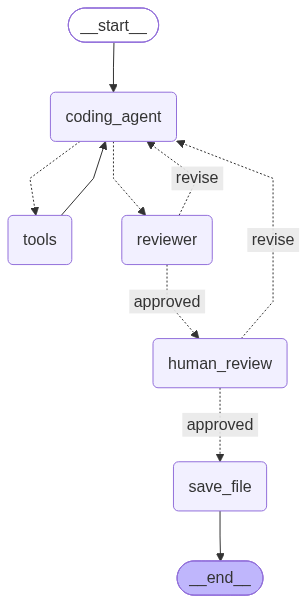

In [76]:
display_graph(coding_subgraph, Path("test_graph.png"))

In [77]:
Path("/content/example.py").write_text(
    """def divide(a, b):
    return a / b
""",
    encoding="utf-8"
)

revision_config = {
    "configurable": {
        "thread_id": "human-revision-test-3"
    }
}

revision_state = {
    "user_request": "Modify the file to handle division by zero.",
    "task_type": "modify",
    "file_path": "/content/example.py",
    "original_content": "",
    "proposed_content": "",
    "review": None,
    "human_feedback": "",
    "revision_count": 0,
    "final_answer": "",
    "messages": []
}

In [78]:
result = coding_subgraph.invoke(
    revision_state,
    config=revision_config
)

if "__interrupt__" in result:
    print_interrupts(result["__interrupt__"])

In [79]:
result = coding_subgraph.invoke(
    Command(
        resume="Use ZeroDivisionError instead of ValueError and add a docstring."
    ),
    config=revision_config
)

if "__interrupt__" in result:
    print_interrupts(result["__interrupt__"])

In [80]:
result = coding_subgraph.invoke(
    Command(resume="approve"),
    config=revision_config
)

In [81]:
print(Path("/content/example.py").read_text())

def divide(a, b):
    """Return a divided by b, raising ZeroDivisionError if b is zero."""
    if b == 0:
        raise ZeroDivisionError("Cannot divide by zero.")
    return a / b


In [82]:
def execute_workflow(
    user_request: str,
    task_type: Literal["create", "modify"] = "create",
    file_path: str = "",
    thread_id: str = "default-thread"
):
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    initial_state = {
        "user_request": user_request,
        "task_type": task_type,
        "file_path": file_path,
        "original_content": "",
        "proposed_content": "",
        "review": None,
        "human_feedback": "",
        "revision_count": 0,
        "final_answer": "",
        "messages": []
    }

    result = coding_subgraph.invoke(
        initial_state,
        config=config
    )

    while "__interrupt__" in result:
        print_interrupts(result["__interrupt__"])

        human_decision = input(
            "\nType 'approve' or provide revision feedback: "
        ).strip()

        if not human_decision:
            print("Please enter 'approve' or revision feedback.")
            continue

        result = coding_subgraph.invoke(
            Command(resume=human_decision),
            config=config
        )

    return result

In [83]:
result = execute_workflow(
    user_request=(
        "Create a Python function that checks "
        "whether a number is prime."
    ),
    task_type="create",
    thread_id="execute-create-1"
)


Type 'approve' or provide revision feedback: approve


In [84]:
print(result["final_answer"])

Workflow completed. The proposed code was approved.


In [85]:
Path("/content/example.py").write_text(
    """def divide(a, b):
    return a / b
""",
    encoding="utf-8"
)

35

In [86]:
result = execute_workflow(
    user_request="Modify the function to handle division by zero.",
    task_type="modify",
    file_path="/content/example.py",
    thread_id="execute-modify-1"
)


Type 'approve' or provide revision feedback: Use ZeroDivisionError and add a docstring.



Type 'approve' or provide revision feedback: approve


In [87]:
print("Revision count:", result["revision_count"])
print("Final answer:", result["final_answer"])

print("\nSaved file:")
print(Path("/content/example.py").read_text())

Revision count: 1
Final answer: Workflow completed. Success: File '/content/example.py' was updated.

Saved file:
def divide(a, b):
    """Divide a by b, raising ZeroDivisionError if b is zero."""
    if b == 0:
        raise ZeroDivisionError("Cannot divide by zero")
    return a / b
